# Advanced Sequential Multi-Agent Orchestration (Clean)

This notebook keeps the same base architecture (agent subgraphs + orchestration graph), removes redundant repeated blocks, and enforces sequential shared-state execution across agents.

In [ ]:
# Optional install (run once if needed)
# %pip install -q langgraph langchain langchain-community langchain-openai sentence-transformers chromadb

In [1]:
import os
import json
import requests
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv
from typing import List, TypedDict, Optional, Dict, Any
from IPython.display import Markdown, display

from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, END
from tavily import TavilyClient
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
import os
import time
from dotenv import load_dotenv
import re

load_dotenv()


OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "").strip()
OPENROUTER_MODEL = os.getenv("OPENROUTER_MODEL", "openai/gpt-4o-mini")

embedding_fn = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

def call_llm(prompt: str, temperature: float = 0.1) -> str:
    if not OPENROUTER_API_KEY:
        return ""
    try:
        llm = ChatOpenAI(
            model=OPENROUTER_MODEL,
            openai_api_key=OPENROUTER_API_KEY,
            base_url="https://openrouter.ai/api/v1",
            temperature=temperature,
        )
        return llm.invoke(prompt).content.strip()
    except Exception:
        return ""

def parse_json_payload(raw: str, fallback: Dict[str, Any]) -> Dict[str, Any]:
    text = (raw or "").strip()
    if not text:
        return fallback
    text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text, flags=re.MULTILINE)
    try:
        parsed = json.loads(text)
        return parsed if isinstance(parsed, dict) else fallback
    except Exception:
        return fallback

c:\Users\KISHORE S\anaconda3\envs\agent\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\KISHORE S\AppData\Local\Temp\ipykernel_20164\2958364485.py:28: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_fn = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2384.23it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+----------

In [2]:
class GraphState(TypedDict, total=False):
    user_input: Dict[str, Any]
    query: str

    selected_agent: str
    route_target: str
    required_agents: List[str]
    orchestration_plan: Dict[str, Any]

    retrieval_query: str
    raw_docs: List[str]
    context: str

    sponsors_answer: str
    pricing: Dict[str, Any]
    emails: List[Dict[str, Any]]
    email_logs: List[Dict[str, Any]]

    agent_outputs: Dict[str, Any]
    final_answer: str
    logs: List[str]

AGENT_CANONICAL = [
    "sponsor", "speaker", "exhibitor", "venue",
    "pricing", "community", "event_ops", "outreach"
]

AGENT_TO_SELECTED = {
    "sponsor": "SPONSOR",
    "speaker": "SPEAKER",
    "exhibitor": "EXHIBITOR",
    "venue": "VENUE",
    "pricing": "PRICING",
    "community": "COMMUNITY",
    "event_ops": "EVENT_OPS",
    "outreach": "EMAIL_OUTREACH",
}

DB_BY_AGENT = {
    "sponsor": "sponsor_vector_db",
    "speaker": "speaker_vector_db",
    "exhibitor": "exhibitor_vector_db",
    "venue": "venue_vector_db",
    "pricing": "pricing_vector_db",
    "community": "community_vector_db",
    "event_ops": "event_ops_vector_db",
    "outreach": "contact_vector_db",
}

def extract_query_text(state: GraphState) -> str:
    q = str(state.get("query", "")).strip()
    if q:
        return q
    ui = state.get("user_input", {})
    if isinstance(ui, dict):
        objective = str(ui.get("objective", "")).strip()
        if objective:
            return objective
        return json.dumps(ui, ensure_ascii=True)
    return str(ui)

In [3]:
def get_vectordb(agent: str) -> Chroma:
    db_path = DB_BY_AGENT[agent]
    return Chroma(persist_directory=db_path, embedding_function=embedding_fn)

def retrieve_docs(agent: str, retrieval_query: str, k: int = 6) -> List[str]:
    try:
        vectordb = get_vectordb(agent)
        docs = vectordb.similarity_search(retrieval_query, k=k)
        return [d.page_content for d in docs]
    except Exception:
        return []

def build_domain_subgraph(agent: str):
    def build_query_node(state: GraphState) -> Dict[str, Any]:
        query_text = extract_query_text(state)
        retrieval_query = state.get("retrieval_query") or f"{agent} intelligence for: {query_text}"
        return {
            "selected_agent": AGENT_TO_SELECTED[agent],
            "retrieval_query": retrieval_query,
        }

    def retrieve_node(state: GraphState) -> Dict[str, Any]:
        retrieval_query = str(state.get("retrieval_query", "")).strip()
        docs = retrieve_docs(agent, retrieval_query, k=6)
        context = "\n\n".join(docs)
        return {
            "raw_docs": docs,
            "context": context,
        }

    def generate_node(state: GraphState) -> Dict[str, Any]:
        query_text = extract_query_text(state)
        context = str(state.get("context", ""))
        prompt = (
            f"You are the {agent} specialist agent.\n"
            "Use only provided context and user objective.\n"
            "Produce actionable output and mention assumptions.\n\n"
            f"User query: {query_text}\n\n"
            f"Context:\n{context[:12000]}\n"
        )
        answer = call_llm(prompt)
        if not answer:
            answer = f"No LLM response. Retrieved {len(state.get('raw_docs', []))} documents for {agent}."

        outputs = dict(state.get("agent_outputs", {}))
        outputs[agent] = {
            "answer": answer,
            "context": context,
        }

        result: Dict[str, Any] = {
            "sponsors_answer": answer,
            "agent_outputs": outputs,
        }

        if agent == "pricing":
            parsed = parse_json_payload(answer, {})
            if parsed:
                result["pricing"] = parsed

        if agent == "outreach":
            emails = parse_json_payload(answer, {}).get("emails", [])
            if not isinstance(emails, list):
                emails = []
            email_logs = [{
                "to": e.get("to", ""),
                "subject": e.get("subject", ""),
                "status": "pending",
            } for e in emails if isinstance(e, dict)]
            result["emails"] = emails
            result["email_logs"] = email_logs

        return result

    b = StateGraph(GraphState)
    b.add_node("build_query", build_query_node)
    b.add_node("retrieve", retrieve_node)
    b.add_node("generate", generate_node)
    b.set_entry_point("build_query")
    b.add_edge("build_query", "retrieve")
    b.add_edge("retrieve", "generate")
    b.add_edge("generate", END)
    return b.compile()

sponsor_subgraph = build_domain_subgraph("sponsor")
speaker_subgraph = build_domain_subgraph("speaker")
exhibitor_subgraph = build_domain_subgraph("exhibitor")
venue_subgraph = build_domain_subgraph("venue")
pricing_subgraph = build_domain_subgraph("pricing")
community_subgraph = build_domain_subgraph("community")
event_ops_subgraph = build_domain_subgraph("event_ops")
email_subgraph = build_domain_subgraph("outreach")

In [4]:
def fallback_plan_from_query(query_text: str) -> Dict[str, Any]:
    q = query_text.lower()
    agents: List[str] = []

    rules = [
        ("speaker", ["speaker", "talk", "panel"]),
        ("sponsor", ["sponsor", "brand", "funding"]),
        ("community", ["community", "gtm", "audience", "network"]),
        ("pricing", ["price", "pricing", "ticket", "revenue"]),
        ("venue", ["venue", "hall", "location"]),
        ("event_ops", ["ops", "operations", "logistics"]),
        ("outreach", ["mail", "email", "outreach", "contact"]),
        ("exhibitor", ["exhibitor", "booth", "expo"]),
    ]

    for agent, keywords in rules:
        if any(k in q for k in keywords):
            agents.append(agent)

    if not agents:
        agents = ["sponsor"]

    handoffs = [{
        "from": agents[i],
        "to": agents[i + 1],
        "reason": "Sequential dependency",
    } for i in range(len(agents) - 1)]

    return {
        "agents": agents,
        "handoffs": handoffs,
        "objective": query_text,
        "requires_combination": len(agents) > 1,
    }

def normalize_agents(raw_agents: Any) -> List[str]:
    alias = {
        "gtm": "community",
        "ops": "event_ops",
        "email": "outreach",
        "email_outreach": "outreach",
    }
    normalized = []
    for item in (raw_agents or []):
        agent = alias.get(str(item).strip().lower(), str(item).strip().lower())
        if agent in AGENT_CANONICAL and agent not in normalized:
            normalized.append(agent)
    return normalized

def planner_node(state: GraphState) -> Dict[str, Any]:
    query_text = extract_query_text(state)
    logs = list(state.get("logs", []))

    planner_prompt = (
        "You are a multi-agent orchestration planner. Return strict JSON only.\n"
        "Keys: agents (ordered list), handoffs (list of {from,to,reason}), objective, requires_combination.\n"
        "Available agents: sponsor, speaker, exhibitor, venue, pricing, community, event_ops, outreach.\n"
        "Choose all required agents in dependency order.\n"
        f"User query: {query_text}\n"
    )
    llm_raw = call_llm(planner_prompt, temperature=0.0)

    plan = parse_json_payload(llm_raw, fallback_plan_from_query(query_text))
    agents = normalize_agents(plan.get("agents", []))
    if not agents:
        agents = fallback_plan_from_query(query_text)["agents"]

    route_target = agents[0] if len(agents) == 1 and not bool(plan.get("requires_combination", len(agents) > 1)) else "coordinator"
    selected_agent = "COORDINATOR" if route_target == "coordinator" else AGENT_TO_SELECTED[route_target]

    logs.append(f"Planner agents: {agents}")

    return {
        "query": query_text,
        "required_agents": agents,
        "route_target": route_target,
        "selected_agent": selected_agent,
        "orchestration_plan": {
            "agents": agents,
            "handoffs": plan.get("handoffs", []),
            "objective": plan.get("objective", query_text),
            "requires_combination": len(agents) > 1,
        },
        "logs": logs,
    }

def route_after_planner(state: GraphState) -> str:
    target = str(state.get("route_target", "sponsor")).lower()
    return {
        "sponsor": "sponsor_node",
        "speaker": "speaker_node",
        "exhibitor": "exhibitor_node",
        "venue": "venue_node",
        "pricing": "pricing_node",
        "community": "community_node",
        "event_ops": "event_ops_node",
        "outreach": "email_node",
        "coordinator": "coordinator_node",
    }.get(target, "sponsor_node")

def topological_order(agents: List[str], handoffs: List[Dict[str, str]]) -> List[str]:
    present = set(agents)
    indeg = {a: 0 for a in agents}
    edges = {a: [] for a in agents}

    for h in handoffs or []:
        left = str(h.get("from", "")).strip().lower()
        right = str(h.get("to", "")).strip().lower()
        if left in present and right in present and right not in edges[left]:
            edges[left].append(right)
            indeg[right] += 1

    ordered = []
    frontier = [a for a in agents if indeg[a] == 0]
    while frontier:
        cur = frontier.pop(0)
        ordered.append(cur)
        for nxt in edges[cur]:
            indeg[nxt] -= 1
            if indeg[nxt] == 0:
                frontier.append(nxt)

    for a in agents:
        if a not in ordered:
            ordered.append(a)
    return ordered

In [5]:
SUBGRAPHS = {
    "sponsor": sponsor_subgraph,
    "speaker": speaker_subgraph,
    "exhibitor": exhibitor_subgraph,
    "venue": venue_subgraph,
    "pricing": pricing_subgraph,
    "community": community_subgraph,
    "event_ops": event_ops_subgraph,
    "outreach": email_subgraph,
}

def run_agent(agent: str, shared_state: GraphState) -> Dict[str, Any]:
    sg = SUBGRAPHS[agent]
    invoke_state = dict(shared_state)
    invoke_state["selected_agent"] = AGENT_TO_SELECTED[agent]
    result = sg.invoke(invoke_state)
    return {
        "answer": result.get("sponsors_answer", ""),
        "context": result.get("context", ""),
        "pricing": result.get("pricing", {}),
        "emails": result.get("emails", []),
        "email_logs": result.get("email_logs", []),
        "raw": result,
    }

def hydrate_shared_state(shared_state: GraphState, outputs: Dict[str, Any], ordered_agents: List[str]) -> GraphState:
    for agent in ordered_agents:
        packet = outputs.get(agent, {})
        if packet.get("answer"):
            shared_state["sponsors_answer"] = packet["answer"]
        if packet.get("context"):
            shared_state["context"] = packet["context"]
        if packet.get("pricing"):
            shared_state["pricing"] = packet["pricing"]
        if packet.get("emails") is not None:
            shared_state["emails"] = packet.get("emails", [])
        if packet.get("email_logs") is not None:
            shared_state["email_logs"] = packet.get("email_logs", [])
    return shared_state

def build_outreach_query(shared_state: GraphState, outputs: Dict[str, Any], ordered_agents: List[str]) -> str:
    snippets = []
    for agent in ordered_agents:
        if agent == "outreach":
            continue
        answer = str(outputs.get(agent, {}).get("answer", "")).strip()
        if answer:
            snippets.append(f"[{agent}] {answer[:400]}")
    if not snippets:
        return f"outreach contacts for: {extract_query_text(shared_state)}"
    return (
        "Generate outreach using consolidated multi-agent intelligence.\n"
        f"User request: {extract_query_text(shared_state)}\n"
        f"Agent intelligence:\n{chr(10).join(snippets)}\n"
        "Prioritize speaker, sponsor, and community contacts where relevant."
    )

def coordinator_node(state: GraphState) -> Dict[str, Any]:
    logs = list(state.get("logs", []))
    outputs = dict(state.get("agent_outputs", {}))

    plan = dict(state.get("orchestration_plan", {}))
    agents = normalize_agents(plan.get("agents", [])) or ["sponsor"]
    ordered_agents = topological_order(agents, plan.get("handoffs", []))

    shared_state = dict(state)

    for agent in ordered_agents:
        shared_state = hydrate_shared_state(shared_state, outputs, ordered_agents)
        if agent == "outreach":
            shared_state["retrieval_query"] = build_outreach_query(shared_state, outputs, ordered_agents)
            logs.append("Coordinator injected cross-agent context for outreach")

        logs.append(f"Coordinator executing: {agent}")
        outputs[agent] = run_agent(agent, shared_state)

    shared_state = hydrate_shared_state(shared_state, outputs, ordered_agents)

    return {
        "required_agents": ordered_agents,
        "agent_outputs": outputs,
        "sponsors_answer": shared_state.get("sponsors_answer", ""),
        "context": shared_state.get("context", ""),
        "pricing": shared_state.get("pricing", {}),
        "emails": shared_state.get("emails", []),
        "email_logs": shared_state.get("email_logs", []),
        "logs": logs,
    }

def combine_results_node(state: GraphState) -> Dict[str, Any]:
    query_text = extract_query_text(state)
    outputs = state.get("agent_outputs", {})
    ordered_agents = state.get("required_agents", [])

    prompt = (
        "You are a senior coordinator. Produce final sequential plan from agent outputs.\n"
        "Include clear step-by-step execution order and conflict resolution notes.\n"
        f"User query: {query_text}\n"
        f"Execution order: {ordered_agents}\n"
        f"Outputs JSON: {json.dumps(outputs, ensure_ascii=True)}\n"
    )
    final_text = call_llm(prompt)
    if not final_text:
        final_text = f"Sequential execution completed for agents: {ordered_agents}"

    logs = list(state.get("logs", []))
    logs.append("Combined outputs into final answer")

    return {
        "final_answer": final_text,
        "sponsors_answer": final_text,
        "logs": logs,
        "emails": state.get("emails", []),
        "email_logs": state.get("email_logs", []),
    }

def make_direct_node(agent: str):
    def _node(state: GraphState) -> Dict[str, Any]:
        output = run_agent(agent, state)
        return {
            "required_agents": [agent],
            "agent_outputs": {agent: output},
            "sponsors_answer": output.get("answer", ""),
            "context": output.get("context", ""),
            "pricing": output.get("pricing", {}),
            "emails": output.get("emails", []),
            "email_logs": output.get("email_logs", []),
        }
    return _node

builder = StateGraph(GraphState)
builder.add_node("planner_node", planner_node)
builder.add_node("coordinator_node", coordinator_node)
builder.add_node("combine_results", combine_results_node)

builder.add_node("sponsor_node", make_direct_node("sponsor"))
builder.add_node("speaker_node", make_direct_node("speaker"))
builder.add_node("exhibitor_node", make_direct_node("exhibitor"))
builder.add_node("venue_node", make_direct_node("venue"))
builder.add_node("pricing_node", make_direct_node("pricing"))
builder.add_node("community_node", make_direct_node("community"))
builder.add_node("event_ops_node", make_direct_node("event_ops"))
builder.add_node("email_node", make_direct_node("outreach"))

builder.set_entry_point("planner_node")
builder.add_conditional_edges("planner_node", route_after_planner, {
    "sponsor_node": "sponsor_node",
    "speaker_node": "speaker_node",
    "exhibitor_node": "exhibitor_node",
    "venue_node": "venue_node",
    "pricing_node": "pricing_node",
    "community_node": "community_node",
    "event_ops_node": "event_ops_node",
    "email_node": "email_node",
    "coordinator_node": "coordinator_node",
})

builder.add_edge("coordinator_node", "combine_results")
builder.add_edge("combine_results", END)

for n in [
    "sponsor_node", "speaker_node", "exhibitor_node", "venue_node",
    "pricing_node", "community_node", "event_ops_node", "email_node",
]:
    builder.add_edge(n, END)

graph = builder.compile()
print("Compiled clean advanced orchestration graph")

Compiled clean advanced orchestration graph


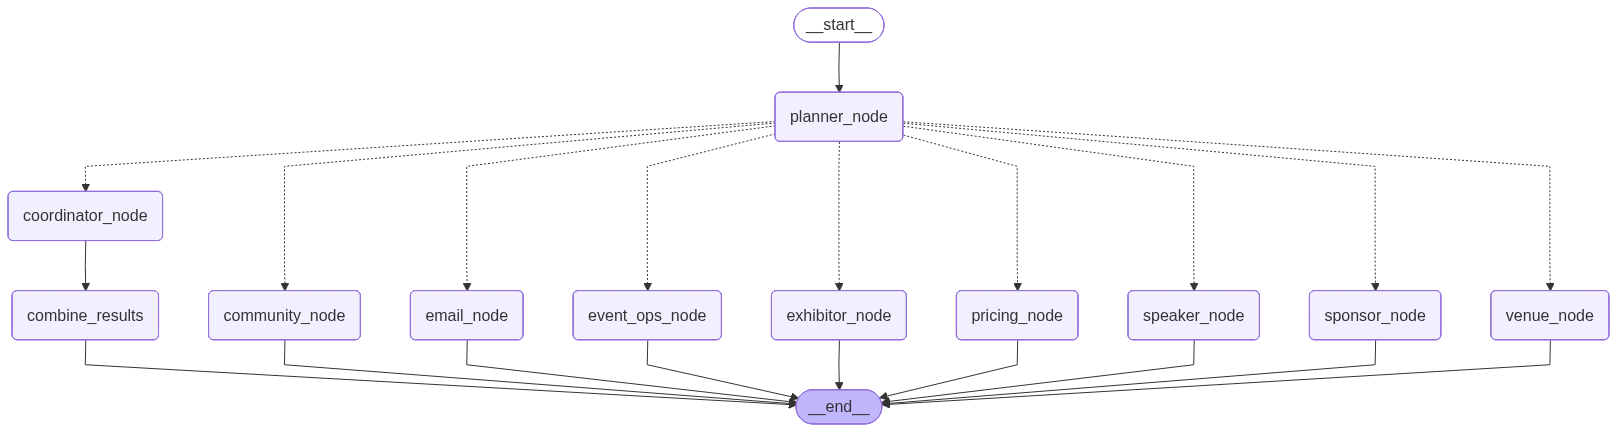

In [6]:
graph

## Test Cases

In [ ]:
# Test 1: Multi-agent sequential plan for speaker + sponsor + community + outreach
test_state_multi: GraphState = {
    "user_input": {
        "event_name": "AI Growth Summit 2026",
        "category": "AI",
        "location": "Bangalore",
        "objective": "Mail all relevant speakers and potential sponsors with strong community alignment",
    },
    "query": "Find relevant speakers, potential sponsors, and community segments; then generate outreach emails in sequence",
    "agent_outputs": {},
    "logs": [],
}

result_multi = graph.invoke(test_state_multi)

print("Required agents:", result_multi.get("required_agents", []))
print("Has final answer:", bool(result_multi.get("final_answer", "").strip()))
print("Emails generated count:", len(result_multi.get("emails", [])))

assert len(result_multi.get("required_agents", [])) >= 2, "Expected multi-agent sequence"
assert result_multi.get("sponsors_answer", "") != "", "Expected final combined answer"
print("Test 1 passed")

In [ ]:
# Test 2: Single-agent route should bypass coordinator
test_state_single: GraphState = {
    "query": "Suggest suitable venues for 1500 people in Bangalore",
    "agent_outputs": {},
    "logs": [],
}

planned = planner_node(test_state_single)
print("Planner route target:", planned.get("route_target"))
assert planned.get("route_target") in {"venue", "coordinator"}, "Unexpected planner route"
print("Test 2 passed")